In [1]:
import os
import pathlib
import random
import zipfile
from pathlib import Path
from timeit import default_timer as timer
from typing import Dict, List, Tuple, override

import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
import pandas as pd
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary
from torchvision import datasets, transforms
from tqdm.auto import tqdm

torch.__version__

/Users/sebastianflajszer/Projects/lp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'2.9.1'

In [2]:
random.seed(42)

In [3]:
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one ...")
    image_path.mkdir(parents=True, exist_ok=True)

    # This downloads the zip file
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get(
            "https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip"
        )
        print("Downloading pizza, steak, sushi data ...")
        f.write(request.content)

    # This unzips the downloaded zip file
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data ...")
        zip_ref.extractall(image_path)

    os.remove(data_path / "pizza_steak_sushi.zip")

data/pizza_steak_sushi directory exists.


In [4]:
device = "cpu"

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"

device

'mps'

## Torch Dataset

Some things to keep in mind:

- Our training data is in image classification format. Image classification format contains separate classes of images in separate directories titled with a particular class name. For example all images of `pizza` are in `/pizza` directory 

```c
pizza_steak_sushi/ <- overall dataset folder
    train/ <- training images
        pizza/ <- class name as folder name
            image01.jpeg
            image02.jpeg
            ...
        steak/
            image24.jpeg
            image25.jpeg
            ...
        sushi/
            image37.jpeg
            ...
    test/ <- testing images
        pizza/
            image101.jpeg
            image102.jpeg
            ...
        steak/
            image154.jpeg
            image155.jpeg
            ...
        sushi/
            image167.jpeg
            ...
```

We want to take this data and make it into usable dataset in pytroch

In [5]:
def walk_through_dir(dir_path):
    """
    Walks through dir_path returning its contents.

    Args:
        dir_path (str or pathlib.Path): target directory

    Returns:
        A print out of:
            number of subdirectories in dir_path
            number of images (files) in each subdirectory
            name of each subdirectory
    """

    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(
            f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'."
        )

In [6]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 58 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi/test/pizza'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 146 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 150 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 154 images in 'data/pizza_steak_sushi/train/pizza'.


In [7]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

Random image path: data/pizza_steak_sushi/test/pizza/2398925.jpg
Image class: pizza
Image height: 512
Image width: 512


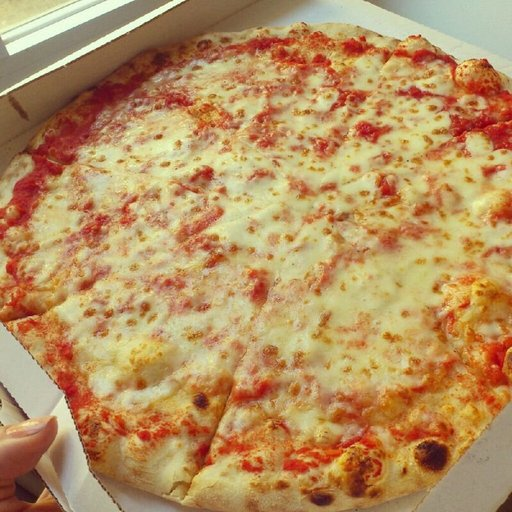

In [8]:
# This retrieves all
image_path_list = list(image_path.glob("*/*/*.jpg"))

# Get random image path
random_image_path = random.choice(image_path_list)

# Get image class from path name
image_class = random_image_path.parent.stem

img = Image.open(random_image_path)

print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")

img

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

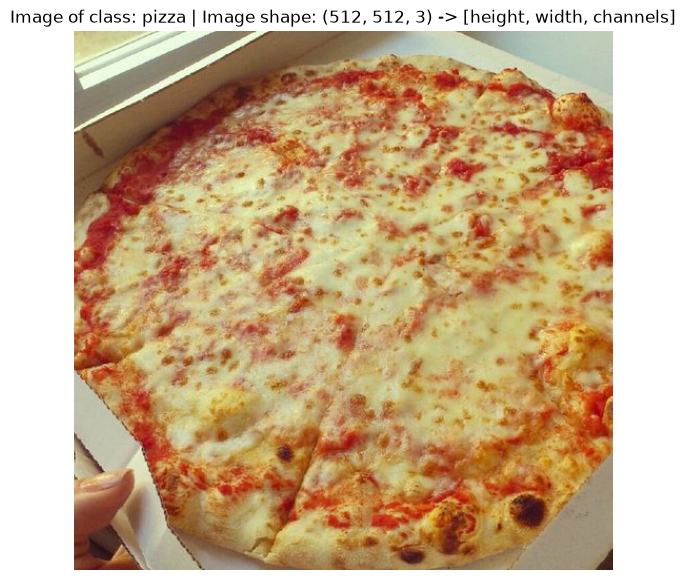

In [9]:
img_as_array = np.asarray(img)

plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(
    f"Image of class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, channels]"
)
plt.axis(False)

In [10]:
# We can use torchvision.transforms to compose a transformation pipeline

data_transform = transforms.Compose(
    [
        # Resize the images to 64x64,
        transforms.Resize(size=(64, 64)),
        # Flip images randomly on the horizontal.
        transforms.RandomHorizontalFlip(
            p=0.5
        ),  # p = probability of flip, 0.5 = 50% chance
        # Turn images into a torch.Tensor
        transforms.ToTensor(),  # this also converts all pixel values from 0 to 255 to be between 0.0 and 1.0
    ]
)

In [11]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them with transform and plot side by side.
    """

    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)

    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)

            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            # Transform and plot image

            # Note: permute() changes shape of image to suit matplotlib
            #       By default pytorch keeps [C, H, W] but matplotlib wants [H, W, C]
            transformed_image = transform(f).permute(1, 2, 0)

            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed image \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

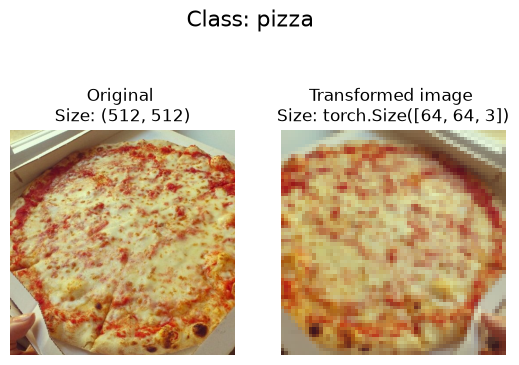

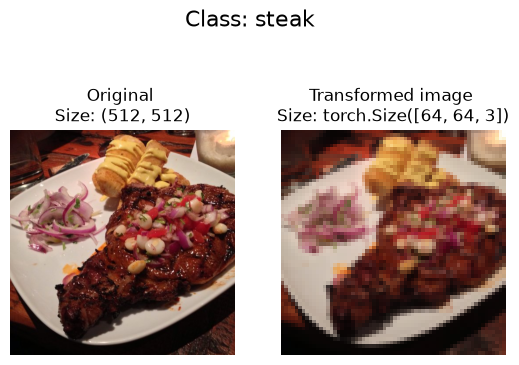

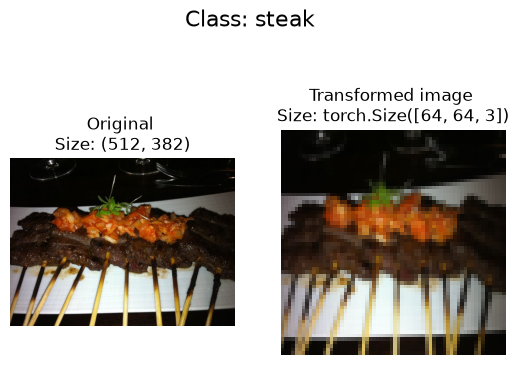

In [12]:
plot_transformed_images(image_path_list, transform=data_transform, n=3)

Option 1: Using `torchvision.datasets.ImageFolder`

In [13]:
train_data = datasets.ImageFolder(
    root=train_dir,  # Target root folder with images stored in standard image classification format
    transform=data_transform,  # Transforms to perform on data (images)
    target_transform=None,  # Transforms to perform on labels (if necessary). None by default
)

test_data = datasets.ImageFolder(
    root=test_dir,
    transform=data_transform,
)

print(f"Train data: \n{train_data}\nTest data:\n{test_data}")

Train data: 
Dataset ImageFolder
    Number of datapoints: 450
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 150
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [14]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [15]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [16]:
len(train_data), len(test_data)

(450, 150)

In [17]:
img, label = train_data[0][0], train_data[0][1]

print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.09

Original shape: torch.Size([3, 64, 64]) -> [channels, height, width]
Image permute shape: torch.Size([64, 64, 3]) -> [height, width, channels]


Text(0.5, 1.0, 'pizza')

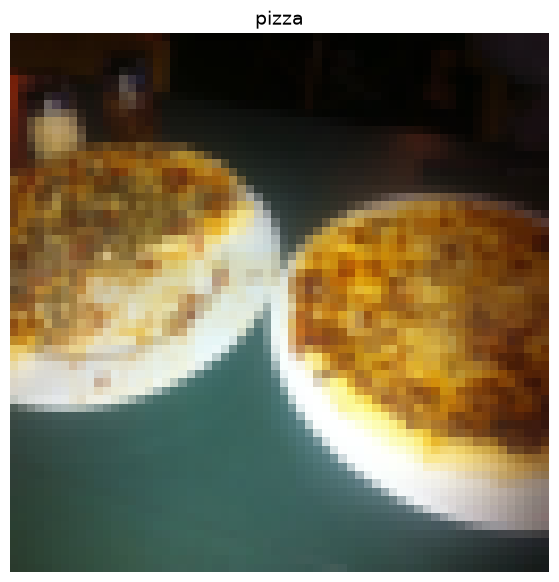

In [18]:
img_permute = img.permute(1, 2, 0)

print(f"Original shape: {img.shape} -> [channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, channels]")

plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.title(class_names[label], fontsize=14)

In [19]:
os.cpu_count()

12

In [20]:
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=1,  # How many samples do we want per batch?
    num_workers=1,  # How many subprocesses to use for data loading?
    shuffle=True,  # Shuffle the data?
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=1,
    num_workers=1,
    shuffle=False,  # We don't usually need to shuffle test data
)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x156cb4d10>,
 <torch.utils.data.dataloader.DataLoader at 0x156b630b0>)

In [21]:
img, label = next(iter(train_dataloader))

print(f"Image shape: {img.shape} -> [batch_size, channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, channels, height, width]
Label shape: torch.Size([1])


## Custom Dataset

In [22]:
target_directory = train_dir
print(f"Target directory: {target_directory}")

class_names_found = sorted(
    [entry.name for entry in list(os.scandir(image_path / "train"))]
)
print(f"Class names found: {class_names_found}")


Target directory: data/pizza_steak_sushi/train
Class names found: ['pizza', 'steak', 'sushi']


In [23]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    """Finds the class folder names in a target directory."""

    # Get class names by scanning target directory
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}.")

    # Create dictionary of index labels
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx


In [24]:
find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [25]:
class ImageFolderCustom(Dataset):
    def __init__(self, targ_dir: str, transform=None) -> None:
        # Get all image paths.
        # NOTE: This line MUST be updated when dealing with .png or .jpeg
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))

        self.transform = transform
        self.classes, self.class_to_idx = find_classes(targ_dir)

    def load_image(self, index: int) -> Image.Image:
        image_path = self.paths[index]
        return Image.open(image_path)

    @override
    def __len__(self) -> int:
        return len(self.paths)

    @override
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        """Returns one sample of data (X, y)"""

        img = self.load_image(index)
        class_name = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_name]

        if self.transform:
            return self.transform(img), class_idx
        else:
            return img, class_idx

In [26]:
train_transforms = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.RandomHorizontalFlip(p=0.5),  # NOTE: Augment train data
        transforms.ToTensor(),
    ]
)

test_transforms = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        # NOTE: Don't augment test data
        transforms.ToTensor(),
    ]
)

In [27]:
train_data_custom = ImageFolderCustom(
    targ_dir=train_dir,
    transform=train_transforms,
)

test_data_custom = ImageFolderCustom(
    targ_dir=test_dir,
    transform=test_transforms,
)

train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x156b70f50>,
 <__main__.ImageFolderCustom at 0x156cb50a0>)

In [28]:
len(train_data_custom), len(test_data_custom)

(450, 150)

In [29]:
classes = train_data_custom.classes
classes

['pizza', 'steak', 'sushi']

In [30]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [31]:
def display_random_images(
    dataset: torch.utils.data.dataset.Dataset,
    classes: List[str] = None,
    n: int = 10,
    display_shape: bool = True,
    seed: int = None,
):
    if n > 10:
        n = 10
        display_shape = False
        print(
            "For display purposes, n shouldn't be larger than 10. Resetting to 10 and removing shape display"
        )

    if seed:
        random.seed(seed)

    random_samples_idx = random.sample(range(len(dataset)), k=n)
    plt.figure(figsize=(16, 8))

    for i, targ_sample in enumerate(random_samples_idx):
        # Extract target image and label from the dataset.
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        # Permute dimensions so that matplotlib is happy
        # Pytorch keeps [C, H, W] but matplotlib wants [H, W, C]
        targ_image_adjust = targ_image.permute(1, 2, 0)

        plt.subplot(1, n, i + 1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")

        if classes:
            title = f"class: {classes[targ_label]}"

            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"

        plt.title(title)

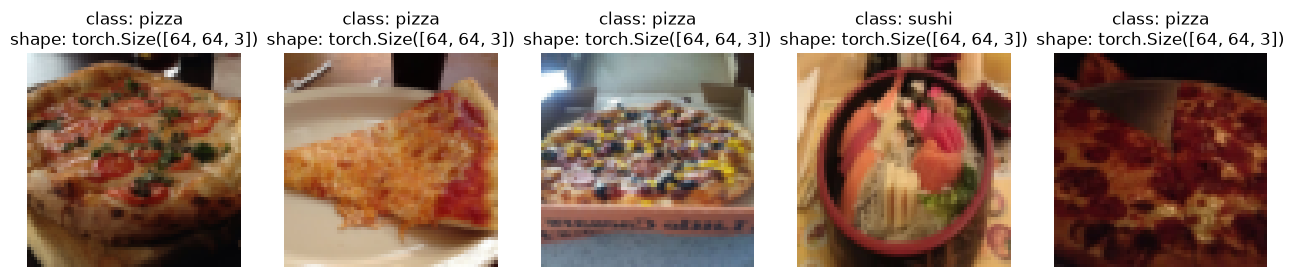

In [32]:
display_random_images(train_data, n=5, classes=class_names, seed=None)

For display purposes, n shouldn't be larger than 10. Resetting to 10 and removing shape display


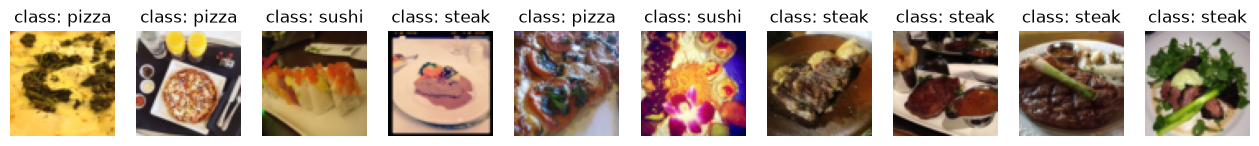

In [33]:
display_random_images(train_data_custom, n=12, classes=class_names, seed=None)

In [34]:
train_dataloader_custom = DataLoader(
    dataset=train_data_custom,
    batch_size=1,  # How many samples per batch
    num_workers=0,  # How many subprocesses to use for dataloading
    shuffle=True,
)

test_dataloader_custom = DataLoader(
    dataset=test_data_custom,
    batch_size=1,
    num_workers=0,
    shuffle=False,
)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x156cf52b0>,
 <torch.utils.data.dataloader.DataLoader at 0x156c78ad0>)

In [35]:
img_custom, label_custom = next(iter(train_dataloader_custom))

print(f"Image shape: {img_custom.shape} -> [batch, channels, height, width]")
print(f"Label shape: {label_custom.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch, channels, height, width]
Label shape: torch.Size([1])


# More data augmentation

*Data augmentation* is the process of altering data in sucha way that artificially increases the diversity of the (training) dataset.

Training on augmented data => hopefully better generalization

In [36]:
train_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.TrivialAugmentWide(
            num_magnitude_bins=31
        ),  # num_magnitude_bins controls the intensity
        transforms.ToTensor(),  # Smash everything to range 0. to 1.
    ]
)

# NOTE: We don't have to augment the test data
test_transforms = transforms.Compose(
    [
        transforms.Resize((244, 244)),
        transforms.ToTensor(),
    ]
)

We don't usually perform data augmentation on the test set. Idea of data augmentation is to artificially increase the diversity of the training set.

Still we need to resize images and convert them to tensors.

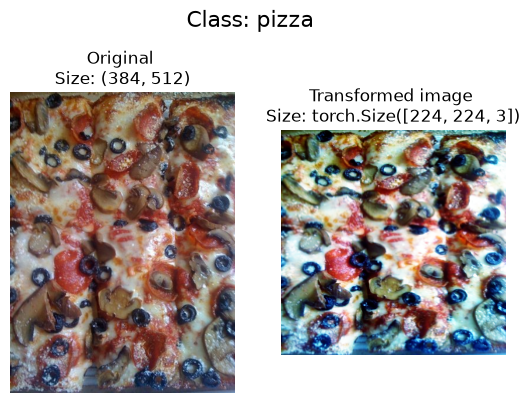

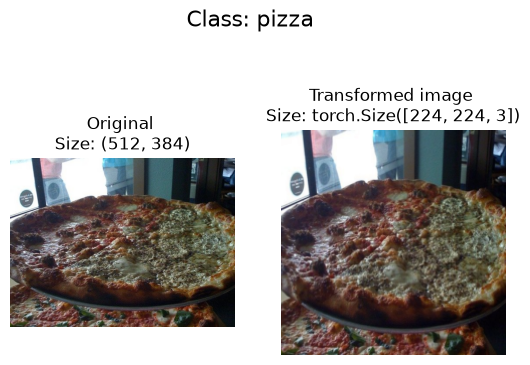

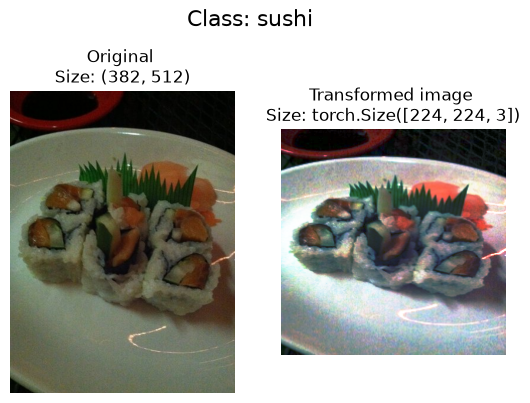

In [37]:
plot_transformed_images(
    image_paths=image_path_list,
    transform=train_transforms,
    n=3,
    seed=None,
)

## Building the TinyVGG model without augmentation

In [38]:
simple_transform = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ]
)

In [39]:
train_data_simple = datasets.ImageFolder(root=train_dir, transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir, transform=simple_transform)

BATCH_SIZE = 32
NUM_WORKERS = 0

print(f"batch size: {BATCH_SIZE}, workers: {NUM_WORKERS}")

train_dataloader_simple = DataLoader(
    dataset=train_data_simple,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True,
)

test_dataloader_simple = DataLoader(
    dataset=test_data_simple,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False,
)

train_dataloader_simple, test_dataloader_simple

batch size: 32, workers: 0


(<torch.utils.data.dataloader.DataLoader at 0x160cf70e0>,
 <torch.utils.data.dataloader.DataLoader at 0x156c205f0>)

In [40]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,  # How is the square going over the image (kernel in convolution)
                stride=1,  # 1 is the default value
                padding=1,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2,  # stride is the same as kernel_size by default
            ),
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features=hidden_units
                * 16
                * 16,  # in_features shape comes from the transformations in other layers (convolutin + max_pooling).
                out_features=output_shape,
            ),
        )

    def forward(self, x: torch.Tensor):
        # x = self.conv_block_1(x)
        # x = self.conv_block_2(x)
        # x = self.classifier(x)

        # NOTE: This leverages the benefits of operator fusion
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))


torch.manual_seed(42)

model_0 = TinyVGG(
    input_shape=3,
    hidden_units=10,
    output_shape=len(train_data.classes),
).to(device)

In [41]:
# # Get batch of images from the dataloader
# img_batch, label_batch = next(iter(train_dataloader_simple))

# # Get a single image from the batch and unsqueeze the image so its shape matches the model
# img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]
# print(f"Single image shape: {img_single.shape}\n")

# model_0.eval()
# with torch.inference_mode():
#     pred = model_0.forward(img_single.to(device))

# print(f"Output logits:\n{pred}\n")
# print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
# print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
# print(f"Actual label:\n{label_single}")

In [42]:
summary(model_0, input_size=[1, 3, 64, 64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

In [ ]:
def train_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device = device,
):
    model.train()

    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model.forward(X)

        # 2. Calculate the loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)

    return train_loss, train_acc

In [44]:
def test_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
):
    model.eval()

    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate metrics
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)

    return test_loss, test_acc

In [45]:
def train(
    model: torch.nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    test_dataloader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: torch.nn.Module = nn.CrossEntropyLoss,
    epochs: int = 5,
):
    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(
            model=model,
            dataloader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
        )

        test_loss, test_acc = test_step(
            model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn,
        )

        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f}"
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        results["train_loss"].append(
            train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss
        )

        results["train_acc"].append(
            train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc
        )

        results["test_loss"].append(
            test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss
        )

        results["test_acc"].append(
            test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc
        )

    return results

In [46]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 5

model_0 = TinyVGG(
    input_shape=3,
    hidden_units=10,
    output_shape=len(train_data.classes),
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=1e-3)

start_time = timer()

model_0_results = train(
    model_0,
    train_dataloader=train_dataloader_simple,
    test_dataloader=test_dataloader_simple,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=NUM_EPOCHS,
)

end_time = timer()
print(f"Total training time: {end_time - start_time:.3f} seconds")

 20%|██        | 1/5 [00:01<00:05,  1.42s/it]

Epoch: 1 | train_loss: 1.1074train_acc: 0.3604 | test_loss: 1.0975 | test_acc: 0.3625


 40%|████      | 2/5 [00:02<00:03,  1.06s/it]

Epoch: 2 | train_loss: 1.1013train_acc: 0.3250 | test_loss: 1.1002 | test_acc: 0.3750


 60%|██████    | 3/5 [00:03<00:01,  1.06it/s]

Epoch: 3 | train_loss: 1.0987train_acc: 0.3354 | test_loss: 1.0960 | test_acc: 0.3625


 80%|████████  | 4/5 [00:03<00:00,  1.13it/s]

Epoch: 4 | train_loss: 1.0957train_acc: 0.3542 | test_loss: 1.0872 | test_acc: 0.5341


100%|██████████| 5/5 [00:04<00:00,  1.07it/s]

Epoch: 5 | train_loss: 1.0739train_acc: 0.5146 | test_loss: 1.0650 | test_acc: 0.3773
Total training time: 4.685 seconds


In [47]:
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [48]:
def plot_loss_curves(results: Dict[str, List[float]]):
    # Loss
    loss = results["train_loss"]
    test_loss = results["test_loss"]

    # Accuracy
    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15, 7))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

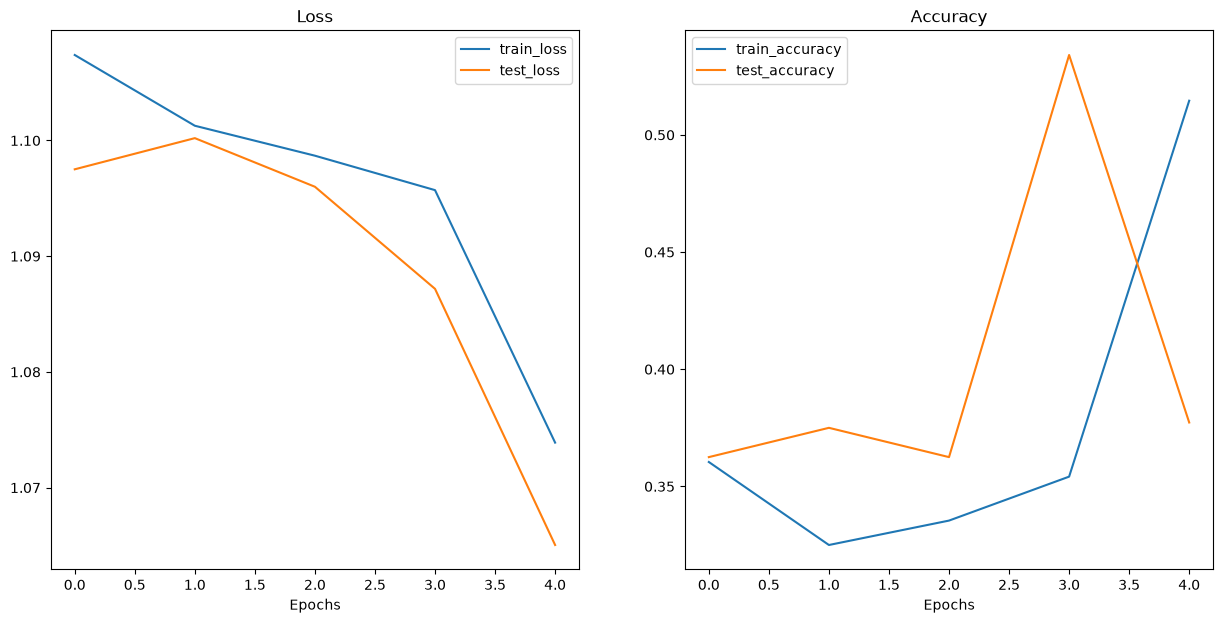

In [49]:
plot_loss_curves(model_0_results)

In [50]:
train_transform_trivial_augment = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.TrivialAugmentWide(num_magnitude_bins=31),
        transforms.ToTensor(),
    ]
)

test_transform = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ]
)

In [51]:
train_data_augmented = datasets.ImageFolder(
    train_dir, transform=train_transform_trivial_augment
)

test_data_augmented = datasets.ImageFolder(
    test_dir,
    transform=test_transform,
)

train_data_augmented, test_data_simple

(Dataset ImageFolder
     Number of datapoints: 450
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 150
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [52]:
torch.manual_seed(42)

train_dataloader_augmented = DataLoader(
    train_data_augmented,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

test_dataloader_augmented = DataLoader(
    test_data_augmented,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

In [53]:
torch.manual_seed(42)

model_1 = TinyVGG(
    input_shape=3, hidden_units=12, output_shape=len(train_data_augmented.classes)
).to(device)

model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=3, bias=True)
  )
)

In [54]:
torch.manual_seed(42)

NUM_EPOCHS = 20

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.0001)

start_time = timer()
model_1_results = train(
    model=model_1,
    train_dataloader=train_dataloader_augmented,
    test_dataloader=test_dataloader_augmented,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=NUM_EPOCHS,
)
end_time = timer()

print(f"Total training time: {end_time - start_time:.3f} seconds")

  5%|▌         | 1/20 [00:00<00:18,  1.03it/s]

Epoch: 1 | train_loss: 1.0981train_acc: 0.3521 | test_loss: 1.1014 | test_acc: 0.2875


 10%|█         | 2/20 [00:01<00:16,  1.10it/s]

Epoch: 2 | train_loss: 1.0971train_acc: 0.3521 | test_loss: 1.1018 | test_acc: 0.2875


 15%|█▌        | 3/20 [00:02<00:15,  1.13it/s]

...

Epoch: 18 | train_loss: 0.9459train_acc: 0.5708 | test_loss: 0.9158 | test_acc: 0.5881


 95%|█████████▌| 19/20 [00:16<00:00,  1.19it/s]

Epoch: 19 | train_loss: 0.9636train_acc: 0.5354 | test_loss: 0.9053 | test_acc: 0.5750


100%|██████████| 20/20 [00:16<00:00,  1.18it/s]

Epoch: 20 | train_loss: 0.9575train_acc: 0.5333 | test_loss: 0.9109 | test_acc: 0.5977
Total training time: 16.999 seconds


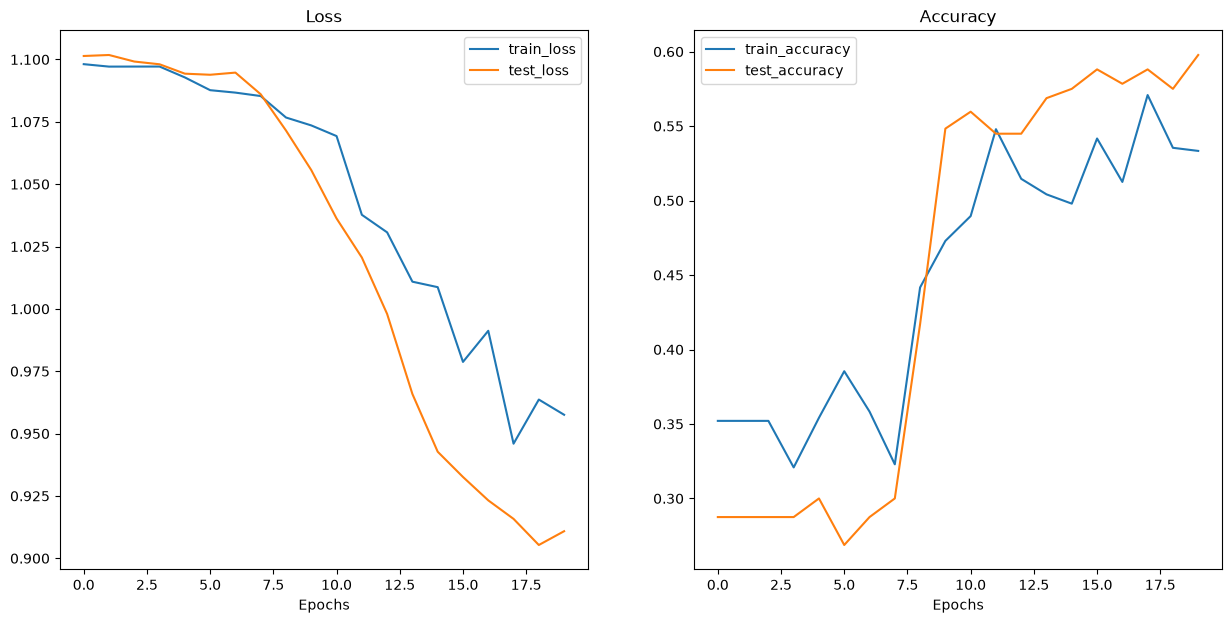

In [55]:
plot_loss_curves(model_1_results)

In [56]:
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.107386,0.360417,1.097508,0.362500
1,1.101273,0.325000,1.100202,0.375000
2,1.098685,0.335417,1.096001,0.362500
3,1.095709,0.354167,1.087180,0.534091
4,1.073890,0.514583,1.065044,0.377273
